In [1]:
import pandas as pd
import numpy as np 

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("data.csv")

In [9]:
df.columns = df.columns.str.lower()

In [12]:
# there are some categorical variables that are encoded as numbers, but we don't want that.
# to fix this, we will use the map() method to map each numerical value to a string like this:

status_values = {
    0: "unknown",
    1: "ok",
    2: "default"
}

df.status = df.status.map(status_values)

home_values = {
    0: "unknown",
    1: "rent",
    2: "owner",
    3: "private",
    4: "ignore",
    5: "parents",
    6: "other",
}

df.home = df.home.map(home_values)

marital_values = {
    0: "unknown",
    1: "single",
    2: "married",
    3: "widow",
    4: "seperated",
    5: "divorced"
}

df.marital = df.marital.map(marital_values)

records_values = {
    0: "unknown",
    1: "no",
    2: "yes"
}

df.records = df.records.map(records_values)

job_values = {
    0: "unknown", 
    1: "fixed",
    2: "part-time",
    3: "freelance",
    4: "other"
}

df.job = df.job.map(job_values)

In [14]:
# there are also some missing values in our data, encoded with very large numbers:
print(df.income.max(), df.assets.max(), df.debt.max())

99999999 99999999 99999999


In [16]:
# so, we use the replace method to decode this missing values back to nan:
df.income = df.income.replace(to_replace=99999999, value=np.nan)
df.assets = df.assets.replace(to_replace=99999999, value=np.nan)
df.debt = df.debt.replace(to_replace=99999999, value=np.nan)

In [18]:
# delete the one record that the target variable is missing:
df = df[df.status != "unknown"].reset_index(drop=True)

In [19]:
# now, let's split the dataframe into test, validation, and training dataset:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1, shuffle=True) 
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1, shuffle=True)

In [20]:
df_train.reset_index(inplace=True, drop=True)
df_val.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)

In [21]:
y_train = df_train.status.apply(lambda x: 0 if x == "ok" else 1)
y_val = df_val.status.apply(lambda x: 0 if x == "ok" else 1)
y_test = df_test.status.apply(lambda x: 0 if x == "ok" else 1)

In [22]:
del df_train["status"]
del df_val["status"]
del df_test["status"]

In [62]:
# Decision Tree:
# in this session, we learn how to train a decision tree model.
# decision trees can be used to solve both regression and classification problems.
from sklearn.tree import DecisionTreeClassifier
# we have some categorical variables as well, so we need dictionary vectorizer as well.
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [63]:
# let's first fill all the missing values with zeros:
df_train = df_train.fillna(0)
df_val = df_val.fillna(0)
df_test = df_test.fillna(0)

In [64]:
train_dicts = df_train.to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [65]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [69]:
# now let's test the decision tree:
val_dicts = df_val.to_dict(orient="records")
X_val = dv.transform(val_dicts)
y_pred = decision_tree.predict_proba(X_val)[:, 1]
# now let's calculate auc for the validation dataset:
roc_auc_score(y_val, y_pred)

np.float64(0.6357723577235773)

In [70]:
# the auc score is not so impressive on the validation dataset.
# so, let's see what is the auc score for the training dataset:
y_pred = decision_tree.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

np.float64(1.0)

In [92]:
# what actually happened here is called overfitting.
# overfitting means our model has simply memorized the data, but fails to generalize it for new data.
# to prevent overfitting, we can limit the depth of our decision tree, so that it does not calculate every possible combination.
decision_tree = DecisionTreeClassifier(max_depth=4)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [93]:
# now, let's compare the auc of the train and validation dataset again:
y_pred = decision_tree.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_pred)

y_pred = decision_tree.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_pred)

print(f"train auc: {auc_train}, validation auc: {auc_val}")

train auc: 0.8164288475670706, validation auc: 0.7728934266086847


In [95]:
# now, let's visualize the tree to see how it works:
from sklearn.tree import export_text
print(export_text(decision_tree, feature_names=dv.get_feature_names_out()))

|--- income <= 89.50
|   |--- seniority <= 2.50
|   |   |--- records=yes <= 0.50
|   |   |   |--- assets <= 4050.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4050.00
|   |   |   |   |--- class: 0
|   |   |--- records=yes >  0.50
|   |   |   |--- age <= 53.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  53.50
|   |   |   |   |--- class: 0
|   |--- seniority >  2.50
|   |   |--- records=no <= 0.50
|   |   |   |--- assets <= 4750.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4750.00
|   |   |   |   |--- class: 0
|   |   |--- records=no >  0.50
|   |   |   |--- assets <= 3550.00
|   |   |   |   |--- class: 0
|   |   |   |--- assets >  3550.00
|   |   |   |   |--- class: 0
|--- income >  89.50
|   |--- records=yes <= 0.50
|   |   |--- job=part-time <= 0.50
|   |   |   |--- seniority <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- seniority >  4.50
|   |   |   |   |--- class: 0
|   |   |--- job=part-time >  0.50
|   |   |   |--- assets <= 7250.00


In [96]:
# now, let's see how decision trees actually work:
# each of the nodes of the decision tree are called condition nodes.
# inside each node, we have the condition, in the form "Feature > Threshold".
# the leaves of the decision tree, are called decision nodes.

In [99]:
# split evaluation (evaluating what threshold would be the most appropriate):
# a way of evaluating our split, is using misclassification rate.
# that is, the number of mistakes we make when using a certain threshold, devided by all predictions.
# we can use average or weighted average of the right side and left side to calculate the total misclassification rate.
# if we have more than one feature, we do the same process for all of them to find out the best thresholds for the splits.

In [100]:
# stopping criteria (how to find out when to stop spilitting our datasets):
# 1- the group is already completely pure. 
# 2- the tree has reached the depth limit.
# 3- the group is too small to be splitted.

In [103]:
# parameter tuning for decision trees (max depth and min samples leaf):
# the min samples leaf means the number of samples that must be in a group, so that it can be a leaf.
for max_depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, None]:
    decision_tree = DecisionTreeClassifier(max_depth=max_depth)
    decision_tree.fit(X_train, y_train)
    y_pred = decision_tree.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_pred)
    print(f"max depth: {max_depth}, auc score: {auc_val}")

max depth: 1, auc score: 0.6159103800340329
max depth: 2, auc score: 0.7108180500409655
max depth: 3, auc score: 0.7519852524106636
max depth: 4, auc score: 0.7728934266086847
max depth: 5, auc score: 0.7654030377513077
max depth: 6, auc score: 0.7379718913468205
max depth: 7, auc score: 0.7339698745824668
max depth: 8, auc score: 0.7056973592991743
max depth: 9, auc score: 0.6960956702590281
max depth: 10, auc score: 0.6637455095481188
max depth: 15, auc score: 0.6463540681918446
max depth: 20, auc score: 0.648131341778534
max depth: None, auc score: 0.6334467763282284


In [104]:
# now let's experiment with min samples leaf to find out its best value:
for max_depth in [3, 4, 5, 6, 7]:
    for min_samples_leaf in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        decision_tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        decision_tree.fit(X_train, y_train)
        y_pred = decision_tree.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, y_pred)
        print(f"max depth: {max_depth}, min samples leaf: {min_samples_leaf}, auc score: {auc_val}")

max depth: 3, min samples leaf: 1, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 2, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 5, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 10, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 15, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 20, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 100, auc score: 0.7509674166509107
max depth: 3, min samples leaf: 200, auc score: 0.7484716707632193
max depth: 3, min samples leaf: 500, auc score: 0.6867807399004222
max depth: 4, min samples leaf: 1, auc score: 0.7728934266086847
max depth: 4, min samples leaf: 2, auc score: 0.7728934266086847
max depth: 4, min samples leaf: 5, auc score: 0.7769269553160648
max depth: 4, min samples leaf: 10, auc score: 0.7775225310392638
max depth: 4, min samples leaf: 15, auc score: 0.7771632948887629
max depth: 4, min samples leaf: 20, auc score: 0.776662254994643
max depth: 4, 

In [118]:
# we can put the above data in a dataframe so that we can work with the data more easily:

scores = []

for max_depth in [1, 2, 3, 4, 5, 6, 7]:
    for min_samples_leaf in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        decision_tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        decision_tree.fit(X_train, y_train)

        y_pred = decision_tree.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, y_pred)

        scores.append((max_depth, min_samples_leaf, auc_val))

In [119]:
df_scores = pd.DataFrame(scores, columns=["max_depth", "min_samples_leaf", "auc"])

In [120]:
df_scores.sort_values(by="auc", ascending=False).head()

,max_depth,min_samples_leaf,auc
60,7,100,0.788980
49,6,15,0.783002
51,6,100,0.782089
50,6,20,0.781663
40,5,15,0.779605


In [121]:
df_scores_pivot = df_scores.pivot(index="min_samples_leaf", columns=["max_depth"], values=["auc"])
df_scores_pivot.round(3)

auc                                          
max_depth             1      2      3      4      5      6      7
min_samples_leaf                                                 
1                 0.616  0.711  0.752  0.773  0.765  0.729  0.728
2                 0.616  0.711  0.752  0.773  0.765  0.736  0.726
5                 0.616  0.711  0.752  0.777  0.774  0.750  0.739
10                0.616  0.711  0.752  0.778  0.776  0.759  0.774
15                0.616  0.711  0.752  0.777  0.780  0.783  0.773
20                0.616  0.711  0.752  0.777  0.779  0.782  0.776
100               0.616  0.711  0.751  0.777  0.774  0.782  0.789
200               0.616  0.711  0.748  0.762  0.762  0.762  0.762
500               0.616  0.676  0.687  0.687  0.687  0.687  0.687

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

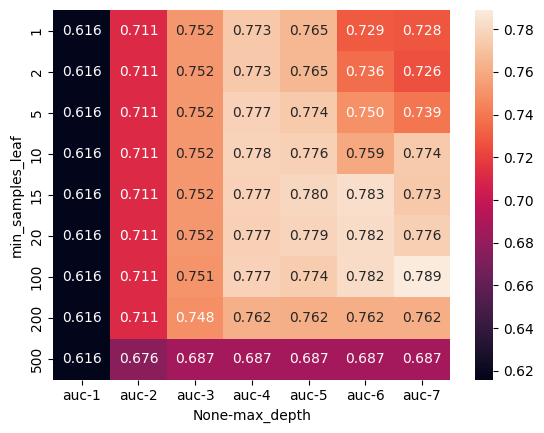

In [122]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [123]:
# now, let's train the final decision tree:
decision_tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)

In [124]:
# Random Forest: putting several deciosion trees together
# to aggregate the decisions, we can take the average of the output probabilities of the decision trees.
# the model is called random forest, because the features of each tree is selected randomly.
from sklearn.ensemble import RandomForestClassifier

In [157]:
# n_estimators is the number of trees in the forest.
random_forest = RandomForestClassifier(n_estimators=10, random_state=1)
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [158]:
y_pred = random_forest.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.7841368878805067)

In [168]:
# every time we re-run the code, we get new results, because the features of the trees are chosen randomly.
# if we fix the random seed (random state), then the result will always be the same.
# now, let's see what happens if we change the number of trees:

scores = []

for n in range(10, 201, 10):

    random_forest = RandomForestClassifier(n_estimators=n, random_state=1)
    random_forest.fit(X_train, y_train)

    y_pred = random_forest.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

In [171]:
df_scores = pd.DataFrame(scores, columns=["number_of_trees", "auc"])

In [172]:
df_scores

,number_of_trees,auc
0,10,0.784137
1,20,0.799263
2,30,0.804922
3,40,0.809009
4,50,0.815037
5,60,0.815602
6,70,0.816181
7,80,0.814269
8,90,0.814143
9,100,0.815223


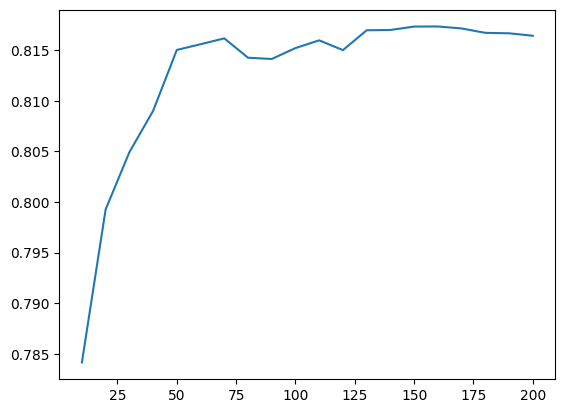

In [170]:
plt.plot(df_scores.number_of_trees, df_scores.auc)

In [202]:
number_of_trees = 70

# now, let's tune the random forest model with the tuning parameters of its decision trees:

scores = []

for n in range(10, 201, 10):
    for max_depth in [5, 6, 7, 8, 9, 10, 15, 20]:
        random_forest = RandomForestClassifier(n_estimators=n, random_state=1, max_depth=max_depth)
        random_forest.fit(X_train, y_train)

        y_pred = random_forest.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((max_depth, n, auc))

In [191]:
columns = ["max_depth", "number_of_trees", "auc"]
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,number_of_trees,auc
0,5,10,0.811908
1,6,10,0.810805
2,7,10,0.807664
3,8,10,0.797529
4,9,10,0.802868


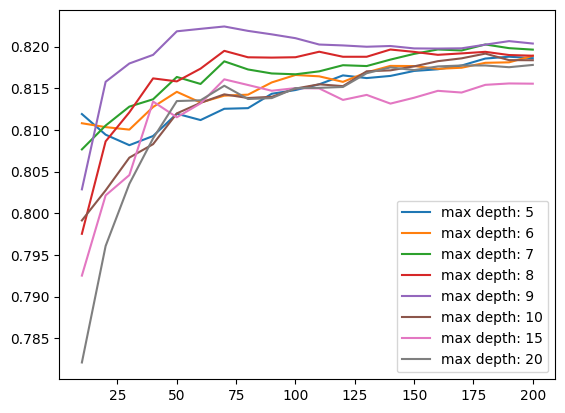

In [192]:
for max_depth in [5, 6, 7, 8, 9, 10, 15, 20]:
    df_subset = df_scores[df_scores.max_depth == max_depth]
    plt.plot(df_subset.number_of_trees, df_subset.auc, label=f"max depth: {max_depth}")

plt.legend()

In [193]:
max_depth = 9

# now, let's tune the min_samples_leaf for the trees of our random forest. 

scores = []

for n in range(10, 201, 10):
    for min_samples_leaf in [1, 3, 5, 10, 15, 20, 100, 200]:
        random_forest = RandomForestClassifier(n_estimators=n, random_state=1, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        random_forest.fit(X_train, y_train)

        y_pred = random_forest.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((min_samples_leaf, n, auc))

In [194]:
columns = ["min_samples_leaf", "number_of_trees", "auc"]
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,number_of_trees,auc
0,1,10,0.802868
1,3,10,0.806791
2,5,10,0.803895
3,10,10,0.805338
4,15,10,0.808275


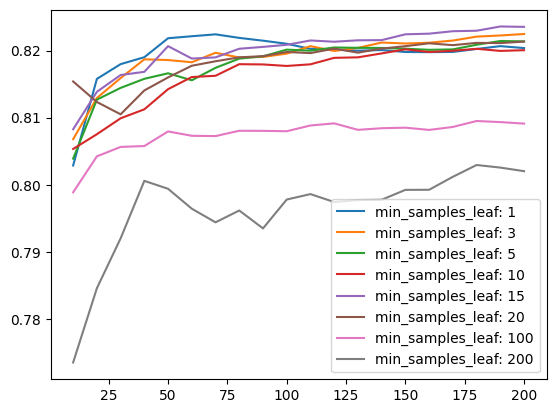

In [195]:
for min_samples_leaf in [1, 3, 5, 10, 15, 20, 100, 200]:
    df_subset = df_scores[df_scores.min_samples_leaf == min_samples_leaf]
    plt.plot(df_subset.number_of_trees, df_subset.auc, label=f"min_samples_leaf: {min_samples_leaf}")

plt.legend()

In [200]:
min_samples_leaf = 3

random_forest = RandomForestClassifier(n_estimators=number_of_trees, random_state=1, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

# there are some other important parameters that we can tune, like max_features and bootstrap.

np.float64(0.8196760572256886)

In [203]:
# Another Way Of Aggregating Decision Trees, Gradient Boost.
# in random forest, the trees are trained independently, and then we calculate their average probability.
# however, in gradient boost, the trees are trained sequentially, and each tree is designed to fix the errors of the previous tree.
# we use the xgboost to implement the gradient boosting trees. 
import xgboost as xgb

In [209]:
# the xgboost library uses a high-performance data structure for training, called Dmatrix.
# so, we first transform our data into Dmatrix, to be able to train our xgboost model.
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [262]:
# now, let's train our xgboost model. 
# to do so, we use the xgb.train() method, with all the parameters below:
# dtrain: the Dmatrix used for training (the equivalent of X_train).
# num_boost_rounds: the number of trees we want to create sequentially when training the model.
# params: parameters used to train our model. could be found at: https://xgboost.readthedocs.io/en/stable/parameter.html.
# here are the most important parameters that we use for training our model:
# "eta": learning rate, "max_depth": controls the depth of the trees, "min_child_weight": the equivalent of min_samples_leaf.
# "objective": the task we want to train the model for, "nthread": number of threads used for training the model, "seed": random seed.
# "verbosity": controls what kind of warnings we have when traning our model.

xgb_params = {
    "eta": 0.3,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=16)

In [263]:
y_pred = model.predict(dval)

In [264]:
roc_auc_score(y_val, y_pred)

np.float64(0.8153746770025838)

In [265]:
# in xgboost, we can evaluate each tree trained in the process on our validation data to see the process:
# also, to see change the evaluation metric to auc, we can use "eval_metric": "auc".
watchlist = [(dtrain, "train"), (dval, "val")]

In [294]:
%%capture output

xgb_params = {
    "eta": 0.3,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)

In [295]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split("\n"):
        it_line, train_line, val_line = line.split("\t")

        it = int(it_line.strip("[]"))
        train = float(train_line.split(":")[1])
        val = float(val_line.split(":")[1])

        results.append((it, train, val))

    columns = ["num_iter", "train_auc", "val_auc"]
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [296]:
df_output = parse_xgb_output(output)

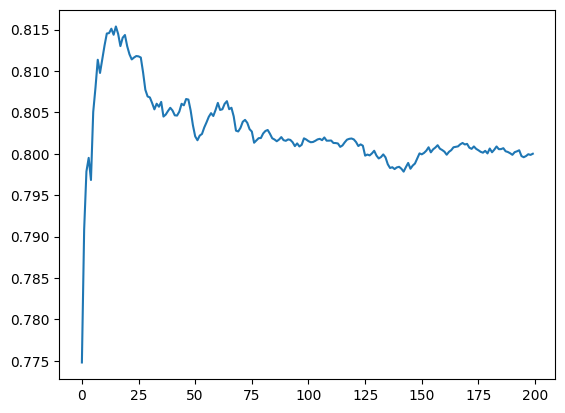

In [297]:
# plt.plot(df_output.num_iter, df_output.train_auc, label="train")
plt.plot(df_output.num_iter, df_output.val_auc, label="validation")
# plt.legend()

In [318]:
scores = {}

In [339]:
%%capture output

# tuning the parameters of the xgboost model:

xgb_params = {
    "eta": 0.01,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)

In [340]:
key = f"eta={xgb_params["eta"]}"
scores[key] = parse_xgb_output(output)

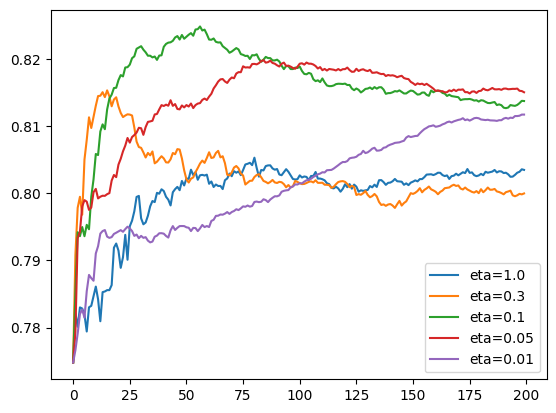

In [342]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.legend()

In [343]:
# so, the best eta would be 0.1 for our model. 
eta = 0.1

In [378]:
scores = {}

In [ ]:
%%capture output

xgb_params = {
    "eta": eta,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)

In [390]:
key = f"max_depth={xgb_params["max_depth"]}"
scores[key] = parse_xgb_output(output)

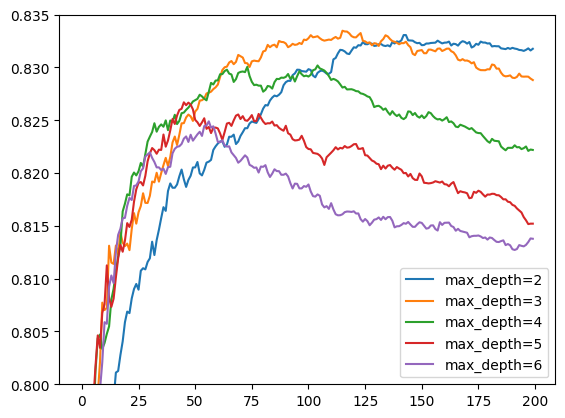

In [394]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.ylim(0.8, 0.835)
plt.legend()

In [395]:
# so, the best max_depth would be 3 for our model.
max_depth = 3

In [407]:
scores = {}

In [415]:
%%capture output

xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": 20,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)

In [416]:
key = f"min_child_weight={xgb_params["min_child_weight"]}"
scores[key] = parse_xgb_output(output)

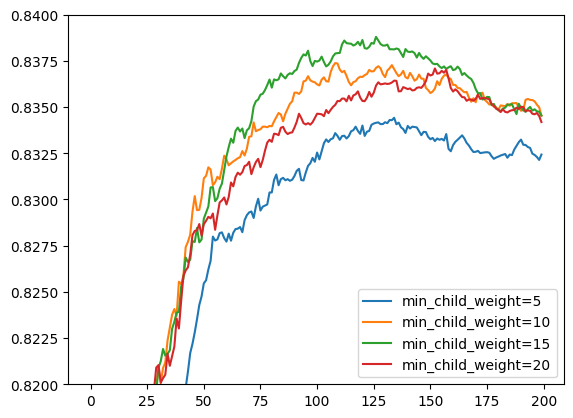

In [417]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.ylim(0.82, 0.84)
plt.legend()

In [418]:
# so, the best min_child_weight for our model is 15.
min_child_weight = 15

In [426]:

xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=125)
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

np.float64(0.8384697800466379)

In [427]:
# there are other parameters to be tuned, like subsample, colsample_bytree, lambda and alpha.

In [428]:
# choosing the best model, decision tree, random forest or xgboost? 
decision_tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)
decision_tree.fit(X_train, y_train)

random_forest = RandomForestClassifier(n_estimators=70, random_state=1, max_depth=9, min_samples_leaf=3)
random_forest.fit(X_train, y_train)

xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=125)

In [432]:
decision_tree_pred = decision_tree.predict_proba(X_val)[:, 1]
random_forest_pred = random_forest.predict_proba(X_val)[:, 1]
xgboost_pred = model.predict(dval)

print(f"""Decision Tree AUC: {roc_auc_score(y_val, decision_tree_pred)}
Random Forest AUC: {roc_auc_score(y_val, random_forest_pred)}
XGBoost AUC: {roc_auc_score(y_val, xgboost_pred)}""")

Decision Tree AUC: 0.7889802735236653
Random Forest AUC: 0.8196760572256886
XGBoost AUC: 0.8384697800466379


In [433]:
# so now that we see that the best model is xgboost, let's train it on our full_train dataset, and test it on the test dataset:
features = list(dv.get_feature_names_out())

df_full_train.reset_index(inplace=True, drop=True)
df_full_train.status = df_full_train.status.apply(lambda x: 0 if x == "ok" else 1)
y_full_train = df_full_train.status
del df_full_train["status"]
dicts_full_train = df_full_train.to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

d_full_train = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)

In [434]:
test_dicts = df_test.to_dict(orient="records")
X_test = dv.transform(test_dicts)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=features)

In [435]:
xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=d_full_train, num_boost_round=125)

In [436]:
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

np.float64(0.8227034947082901)